In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.api import OLS, add_constant

pairs = [
    ("AAPL", "MSFT"),
    ("NVDA", "AMD"),
    ("KO", "PEP"),
    ("XOM", "CVX"),
    ("JPM", "BAC")
]

price_data = pd.read_csv("../data/prices.csv", index_col = 0, parse_dates = True).dropna()

# Split data 
split_idx = int(len(price_data) * 0.5) 
split_date = price_data.index[split_idx] 
train = price_data.loc[:split_date]
test = price_data.loc[split_date:]


In [21]:
# Modify backtest to return the returns
def pair_returns(price_data, t1, t2, window, entry_z, cost = 0.0005):

    # Using Log prices 
    x = np.log(price_data[t1])
    y = np.log(price_data[t2])

    # Estimate beta
    X = add_constant(x)
    model = OLS(y,X).fit()
    beta = model.params.iloc[1]

    # Spread
    spread = y - beta* x

    # Z-Score
    mean = spread.rolling(window).mean()
    std = spread.rolling(window).std()
    zscore = (spread - mean)/ std

    # Compute trading signals
    position = pd.Series(0, index = spread.index)
    position.loc[zscore > entry_z] = -1
    position.loc[zscore < entry_z] = 1
    position = position.ffill().fillna(0)

    spread_ret = spread.diff()
    strategy_ret = position.shift(1) * spread_ret

    # Transaction cost
    trades = position.diff().abs()
    strategy_ret = strategy_ret - trades*cost


    return strategy_ret.fillna(0)

In [48]:
# Build Portifolio Returns
portifolio_returns = pd.DataFrame(index = test.index)

# best window and z-score
best_sharpe = -np.inf
for window in [10,20,30]:
    for z in [1.5, 2, 2.5]:
        r = pair_returns(train, t1, t2, window, z)
        sharpe = r.mean() / r.std()
        if sharpe > best_sharpe:
            best_sharpe = sharpe
            best_window, best_z = window, z

for (t1,t2) in pairs:
    r = pair_returns(test, t1, t2, int(best_window), best_z)
    portifolio_returns[f"{t1}_{t2}"] = r

# Equal weight ie each proportion of stock in portifolio equal
portifolio_returns["Portifolio"] = portifolio_returns.mean(axis = 1)


In [52]:
# Computer Portifolio Metrics

def performance_stats(returns):
    sharpe = returns.mean() / returns.std() * np.sqrt(252)
    cagr = (1+returns).prod() ** (252/len(returns)) - 1

    equity = (1 + returns).cumprod() # ie shows how $1 invested grows over time
    peak = equity.cummax()
    drawdown = (equity - peak)/ peak
    max_dd = drawdown.min()

    return sharpe, cagr, max_dd

sharpe, cagr, max_dd = performance_stats(portifolio_returns["Portifolio"])

print("Portifolio Sharpe:", sharpe)
print("Portifolio CAGR:", cagr)
print("Portifolio Max Drawdown:", max_dd)

Portifolio Sharpe: -0.3705580623948178
Portifolio CAGR: -0.05299644890552346
Portifolio Max Drawdown: -0.11894491647049772


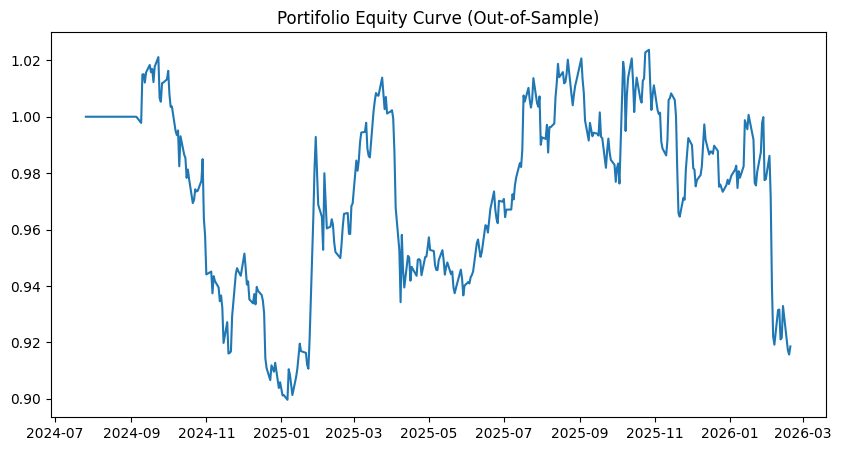

In [54]:
# Plot equity curve
equity = (1 + portifolio_returns["Portifolio"]).cumprod()

plt.figure(figsize=(10,5))
plt.plot(equity)
plt.title("Portifolio Equity Curve (Out-of-Sample)")
plt.show()